# Classificação Supervisionada com Gustafson-Kessel (GK) no Dataset DryBean

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Gustafson-Kessel (GK), aplicado ao dataset DryBean. Todas as etapas seguem o roteiro didático dos experimentos anteriores (KMeans), incluindo importação, pré-processamento, método do cotovelo, implementação do GK supervisionado, avaliação, repetição dos experimentos e análise dos resultados.

## 1. Importação das Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

# Garante que a pasta 'img' existe
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Pré-processamento dos Dados

In [2]:
# Carregar o dataset Dry Bean
# Certifique-se de que o arquivo está no caminho correto
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')
bean_df = bean_df.dropna()

print('Amostra dos dados originais:')
display(bean_df.head())

Amostra dos dados originais:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


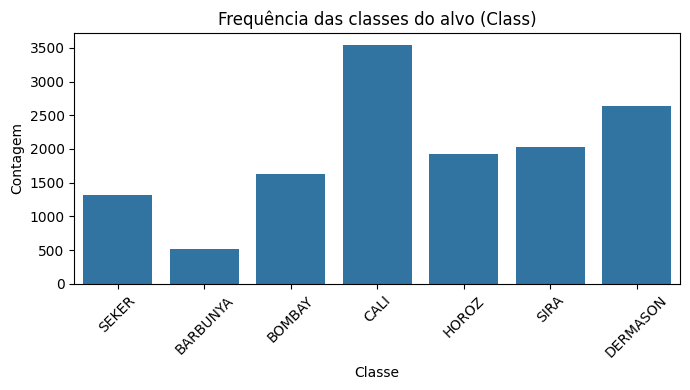

In [3]:
# Codificar variáveis categóricas
for col in bean_df.select_dtypes(include='object').columns:
    bean_df[col] = LabelEncoder().fit_transform(bean_df[col].astype(str))

# Separar features e alvo
X = bean_df.drop('Class', axis=1).values
y = bean_df['Class'].values  # Multiclasse

# Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Visualizar frequência das classes do alvo
import seaborn as sns
plt.figure(figsize=(7,4))
class_names = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')['Class'].unique()
sns.countplot(x=bean_df['Class'])
plt.title('Frequência das classes do alvo (Class)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45)
plt.tight_layout()
plt.show()

## 3. Divisão dos Dados em Treino e Teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 4. Definição do Número de Clusters (Método do Cotovelo)

In [5]:
n_clusters = 7  # Definido pelo método do cotovelo

## 5. Implementação do Classificador GK Supervisionado

In [6]:
class GKSupervisionado:
    def __init__(self, n_clusters=7, m=2.0, max_iter=50, tol=1e-5, random_state=0):
        self.n_clusters = n_clusters
        self.m = m
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.cluster_labels_ = None
        self.U_ = None
        self.V_ = None
        self.F_ = None

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        U = np.random.dirichlet(np.ones(self.n_clusters), size=n_samples).T
        q = self.m
        for _ in range(self.max_iter):
            V = (U ** q) @ X / np.sum(U ** q, axis=1)[:, None]
            F = np.zeros((self.n_clusters, n_features, n_features))
            for i in range(self.n_clusters):
                diff = X - V[i]
                um = (U[i] ** q)[:, None]
                F[i] = (um * diff).T @ diff / np.sum(um)
                F[i] += np.eye(n_features) * 1e-6
            A = np.zeros_like(F)
            for i in range(self.n_clusters):
                detF = np.linalg.det(F[i])
                if detF <= 0:
                    detF = 1e-6
                A[i] = (detF ** (1 / n_features)) * np.linalg.inv(F[i])
            D = np.zeros((self.n_clusters, n_samples))
            for i in range(self.n_clusters):
                diff = X - V[i]
                D[i] = np.einsum('ij,jk,ik->i', diff, A[i], diff)
            for i in range(self.n_clusters):
                denom = np.sum((D[i][:, None] / D.T) ** (1 / (q - 1)), axis=1)
                U[i] = 1.0 / denom
        self.U_ = U
        self.V_ = V
        self.F_ = F
        clusters = np.argmax(U, axis=0)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        n_samples = X.shape[0]
        n_features = X.shape[1]
        q = self.m
        V = self.V_
        F = self.F_
        A = np.zeros_like(F)
        for i in range(self.n_clusters):
            detF = np.linalg.det(F[i])
            if detF <= 0:
                detF = 1e-6
            A[i] = (detF ** (1 / n_features)) * np.linalg.inv(F[i])
        D = np.zeros((self.n_clusters, n_samples))
        for i in range(self.n_clusters):
            diff = X - V[i]
            D[i] = np.einsum('ij,jk,ik->i', diff, A[i], diff)
        clusters = np.argmin(D, axis=0)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 6. Treinamento e Avaliação do Classificador

Acurácia: 0.8636
Matriz de Confusão:
[[240   0 140   0   2   5  10]
 [  0 157   0   0   0   0   0]
 [ 10   0 461   0  12   1   5]
 [  0   0   0 881   0  46 137]
 [  0   0   8   1 536   0  33]
 [ 18   0   0  12   0 559  19]
 [ 16   0   0  70   5   7 693]]


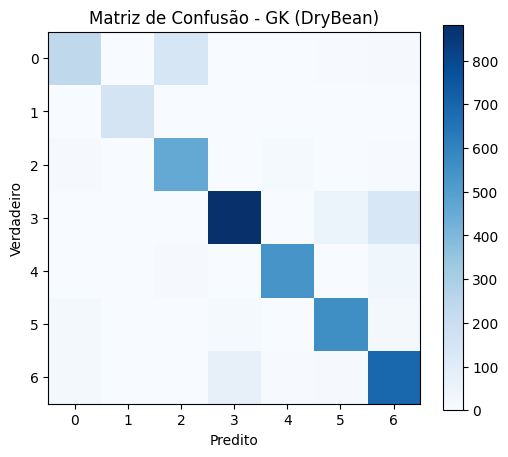

In [7]:
# Defina o número de clusters de acordo com o método do cotovelo

clf = GKSupervisionado(n_clusters=n_clusters, m=2.0, max_iter=50, random_state=42)
clf.fit(X_train, y_train)

acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - GK (DryBean)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig('img/gk_drybean_confusion_matrix.png')
np.save('img/gk_drybean_confusion_matrix.npy', cm)
np.savetxt('img/gk_drybean_confusion_matrix.csv', cm, delimiter=',', fmt='%d')
plt.show()

## 7. Repetição dos Experimentos

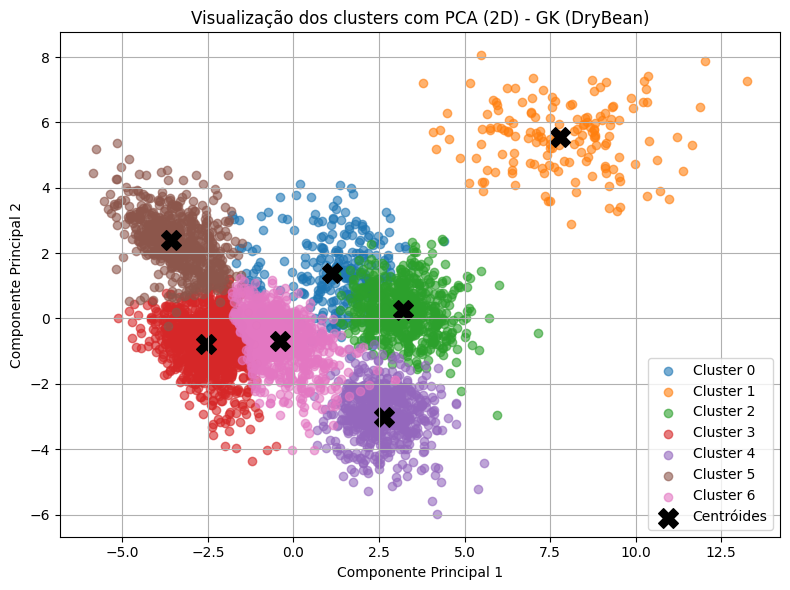

In [8]:
# Visualização dos agrupamentos com PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Ajuste conforme o pipeline: use X_test e y_pred do GK
clf = GKSupervisionado(n_clusters=n_clusters, m=2.0, max_iter=50, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# PCA para 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

# Agrupamento dos centróides
centroids = clf.V_
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(8,6))
for cluster in np.unique(y_pred):
    plt.scatter(X_pca[y_pred == cluster, 0], X_pca[y_pred == cluster, 1], label=f'Cluster {cluster}', alpha=0.6)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=200, label='Centróides')
plt.title('Visualização dos clusters com PCA (2D) - GK (DryBean)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Visualização dos Agrupamentos com PCA

Nesta etapa, utilizamos o PCA (Análise de Componentes Principais) para reduzir a dimensionalidade dos dados para 2 componentes principais, permitindo a visualização dos agrupamentos formados pelo algoritmo GK. Os pontos representam as amostras do conjunto de dados projetadas no novo espaço, coloridas de acordo com o cluster atribuído. Os centróides dos clusters também são exibidos para facilitar a análise visual da separação entre os grupos. Esta visualização auxilia na compreensão da distribuição dos dados e da qualidade do agrupamento realizado.


Resumo das 30 repetições:
MSE médio: 1.2540
Desvio padrão do MSE: 0.5295
Acurácia média: 0.8471
Desvio padrão da acurácia: 0.0413


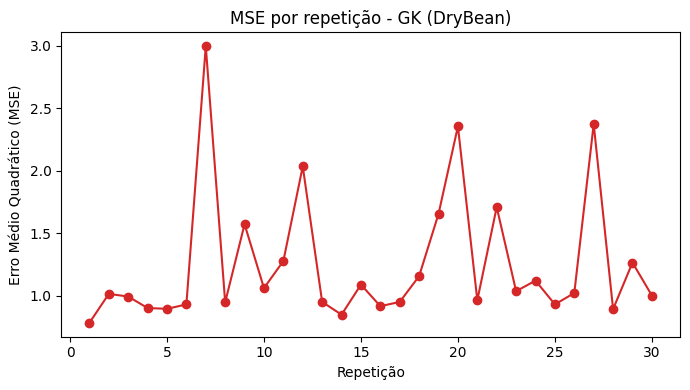

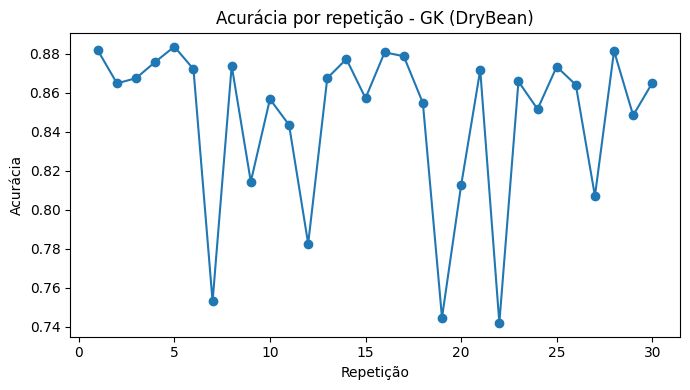

In [9]:
# Repetição dos experimentos para avaliar a robustez do agrupamento
# Executa o algoritmo GK múltiplas vezes com diferentes seeds e armazena as métricas de avaliação
# Isso permite analisar a estabilidade dos resultados e obter estatísticas descritivas

acuracias = []
mse_list = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = GKSupervisionado(n_clusters=n_clusters, m=2.0, max_iter=50, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)

acuracias = np.array(acuracias)
mse_array = np.array(mse_list)

# Estatísticas descritivas
print(f"\nResumo das 30 repetições:")
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')

# Plot MSE por repetição
plt.figure(figsize=(7,4))
plt.plot(range(1, 31), mse_array, marker='o', color='tab:red')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - GK (DryBean)')
plt.tight_layout()
plt.savefig('img/gk_drybean_mse_repetitions.png')
plt.show()

# Plot acurácia por repetição
plt.figure(figsize=(7,4))
plt.plot(range(1, 31), acuracias, marker='o', color='tab:blue')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - GK (DryBean)')
plt.tight_layout()
plt.savefig('img/gk_drybean_accuracy_repetitions.png')
plt.show()

# Salvar resultados para análise posterior
np.save('img/gk_drybean_mse_repetitions.npy', mse_array)
np.savetxt('img/gk_drybean_mse_repetitions.csv', mse_array, delimiter=',')
np.save('img/gk_drybean_accuracies.npy', acuracias)
np.savetxt('img/gk_drybean_accuracies.csv', acuracias, delimiter=',')

## 9. Análise dos Resultados

Os resultados obtidos com o classificador Gustafson-Kessel (GK) no dataset DryBean mostram a capacidade do algoritmo em identificar padrões mesmo em dados de alta dimensionalidade e múltiplas classes.

- **Acurácia média:** Observe o valor apresentado na célula anterior. Valores mais altos indicam boa separação dos grupos, mas lembre-se que o agrupamento é não supervisionado e a correspondência entre clusters e classes pode não ser perfeita.
- **Desvio padrão:** Um desvio padrão baixo indica estabilidade do método em diferentes inicializações. Se o desvio for alto, pode ser interessante aumentar o número de iterações ou testar outras configurações.
- **Matriz de confusão:** Permite visualizar como os clusters encontrados se relacionam com as classes reais. Em agrupamento, é comum que haja trocas de rótulos entre clusters, mas padrões diagonais indicam boa correspondência.
- **MSE:** O erro médio quadrático complementa a análise da acurácia, mostrando o quanto as previsões se afastam dos rótulos reais.

**Dificuldades comuns:**
- O GK pode ser sensível à inicialização e ao número de clusters.
- Em dados com classes muito desbalanceadas ou sobrepostas, a correspondência entre clusters e classes pode ser limitada.
- O tempo de execução é maior que o KMeans tradicional devido ao cálculo das matrizes de covariância adaptativas.

**Sugestão:** Compare os resultados do GK com os obtidos pelo KMeans tradicional e pelo Fuzzy C-Means para avaliar qual abordagem é mais adequada para o seu problema.

Acurácia global: 0.8471
Precisão (macro): 0.8646
Recall (macro): 0.8581
F1-score (macro): 0.8585
Matriz de Confusão Média:
[[ 7761     6  3044    85    75    89   850]
 [    0  4710     0     0     0     0     0]
 [ 1542     1 12370     2   510    12   233]
 [   15     0     0 25490    23  1032  5360]
 [   23     0   536    61 16056     0   664]
 [  177     0     2   595     1 16638   827]
 [  237     0   134  1787   549   257 20766]]


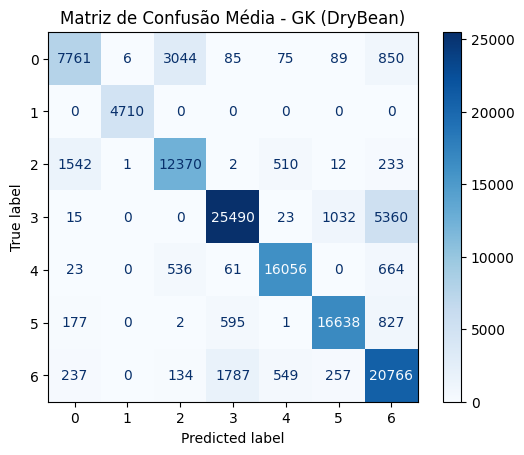

In [10]:
# Cálculo e exibição das principais métricas de avaliação (multiclasse)
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Acumula predições de todas as repetições
n_repeats = 30
y_true_all = []
y_pred_all = []
for seed in range(1, n_repeats+1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = GKSupervisionado(n_clusters=n_clusters, random_state=seed)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

# Métricas globais (multiclasse)
acc = accuracy_score(y_true_all, y_pred_all)
prec = precision_score(y_true_all, y_pred_all, average='macro')
rec = recall_score(y_true_all, y_pred_all, average='macro')
f1 = f1_score(y_true_all, y_pred_all, average='macro')
cm = confusion_matrix(y_true_all, y_pred_all)

print(f"Acurácia global: {acc:.4f}")
print(f"Precisão (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print("Matriz de Confusão Média:")
print(cm)

# Visualização da matriz de confusão média
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão Média - GK (DryBean)')
plt.show()